In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

In [38]:
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]

In [23]:
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/filtered_fibroblasts_gene_exp_transposed_w_clinical.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")

In [24]:
fibr_gene_expression_modified.head()
#fibr_gene_expression_modified["Patient"].head(10)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,MAPK8IP2,ARSA,ACR,RABL2B,Sample,PFS_quartile,OS_quartile,BRCA_status,HRP_status,Segment
0,DSP-1001660016604-A-A02.dcc,1.718431,2.137428,1.836881,1.997698,0.161226,2.480789,4.364810,2.270061,0.033787,...,2.097976,1.991563,-0.115321,2.171023,S130_iOme,1,1,0.0,1.0,stroma
1,DSP-1001660016604-A-A04.dcc,1.622100,2.027326,1.737519,1.901971,0.158211,2.375319,5.534481,2.163770,0.033655,...,2.000658,2.633680,-0.114390,2.073686,S130_iOme,1,1,0.0,1.0,stroma
2,DSP-1001660016604-A-A05.dcc,1.427961,1.505719,1.830641,1.348903,0.165076,2.201253,5.497989,2.271254,0.033957,...,1.451180,2.419147,1.253395,1.018083,S130_iOme,1,1,0.0,1.0,tumor
3,DSP-1001660016604-A-A07.dcc,1.353614,1.787912,1.868598,1.631783,0.164922,2.126467,6.245903,2.308907,0.033950,...,1.166335,2.975583,1.474534,1.239250,S130_iOme,1,1,0.0,1.0,tumor
4,DSP-1001660016604-A-A08.dcc,1.829375,1.602863,1.291572,1.448092,0.164608,1.941802,3.836590,1.731314,0.033936,...,1.550127,2.550633,1.858295,1.623058,S130_iOme,1,1,0.0,1.0,stroma


In [ ]:
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")


,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,PFS_quartile,OS_quartile,BRCA_status,HRP_status,Segment,Patient,PFS_quartile_b12_x,OS_quartile_b12_x,PFS_quartile_b12_y,OS_quartile_b12_y
0,DSP-1001660016604-A-A02.dcc,1.718431,2.137428,1.836881,1.997698,0.161226,2.480789,4.364810,2.270061,0.033787,...,1,1,0.0,1.0,stroma,S130,2.0,1.0,2.0,1.0
1,DSP-1001660016604-A-A04.dcc,1.622100,2.027326,1.737519,1.901971,0.158211,2.375319,5.534481,2.163770,0.033655,...,1,1,0.0,1.0,stroma,S130,2.0,1.0,2.0,1.0
2,DSP-1001660016604-A-A05.dcc,1.427961,1.505719,1.830641,1.348903,0.165076,2.201253,5.497989,2.271254,0.033957,...,1,1,0.0,1.0,tumor,S130,2.0,1.0,2.0,1.0
3,DSP-1001660016604-A-A07.dcc,1.353614,1.787912,1.868598,1.631783,0.164922,2.126467,6.245903,2.308907,0.033950,...,1,1,0.0,1.0,tumor,S130,2.0,1.0,2.0,1.0
4,DSP-1001660016604-A-A08.dcc,1.829375,1.602863,1.291572,1.448092,0.164608,1.941802,3.836590,1.731314,0.033936,...,1,1,0.0,1.0,stroma,S130,2.0,1.0,2.0,1.0
5,DSP-1001660016604-A-A09.dcc,1.668325,1.712678,1.404631,1.009665,0.163619,2.052971,4.802772,1.842360,0.033893,...,1,1,0.0,1.0,tumor,S130,2.0,1.0,2.0,1.0
6,DSP-1001660016604-A-B01.dcc,1.348257,1.783201,1.470482,1.375079,1.313841,2.121579,4.625680,2.303353,0.033958,...,1,1,0.0,1.0,tumor,S130,2.0,1.0,2.0,1.0
7,DSP-1001660016604-A-B02.dcc,1.844499,1.619886,1.967376,1.460052,0.165771,2.619727,5.061084,1.746909,0.033988,...,1,1,0.0,1.0,stroma,S130,2.0,1.0,2.0,1.0
8,DSP-1001660016604-A-B06.dcc,2.121164,1.847555,1.534788,1.690770,0.165045,2.894431,4.385041,1.975461,0.033955,...,1,1,0.0,1.0,stroma,S130,2.0,1.0,2.0,1.0
9,DSP-1001660016604-A-B07.dcc,1.919169,1.674062,2.040190,1.522548,0.163847,2.013905,4.474236,2.478597,0.033903,...,1,1,0.0,1.0,tumor,S130,2.0,1.0,2.0,1.0


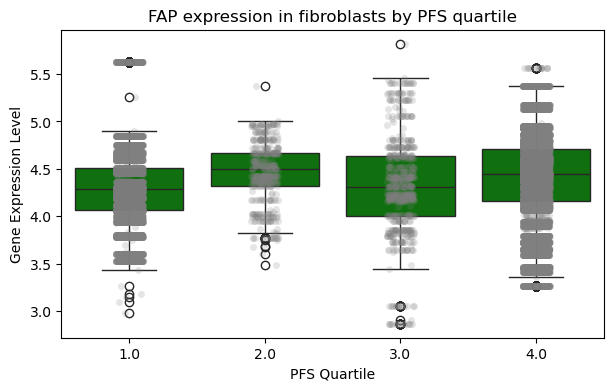

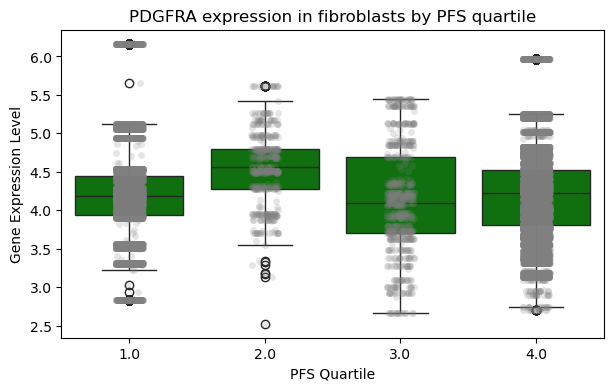

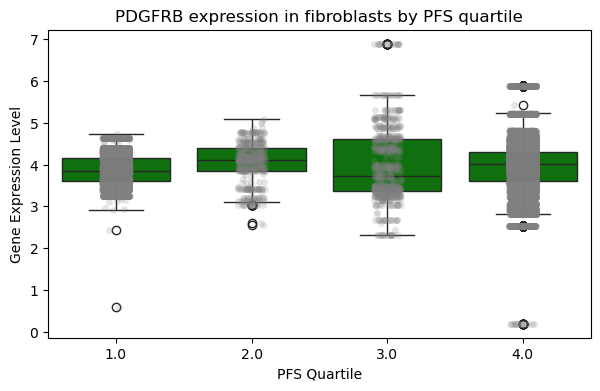

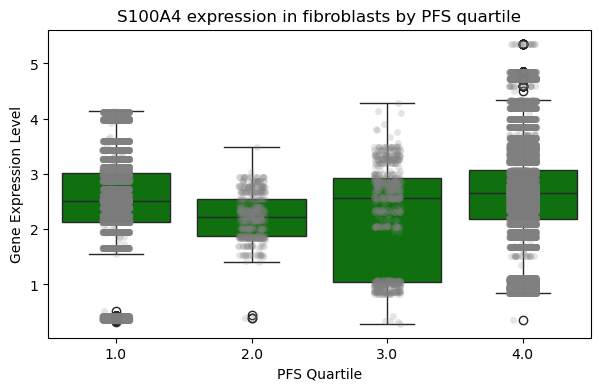

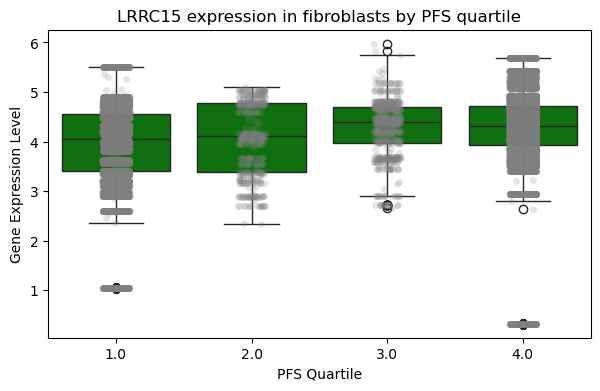

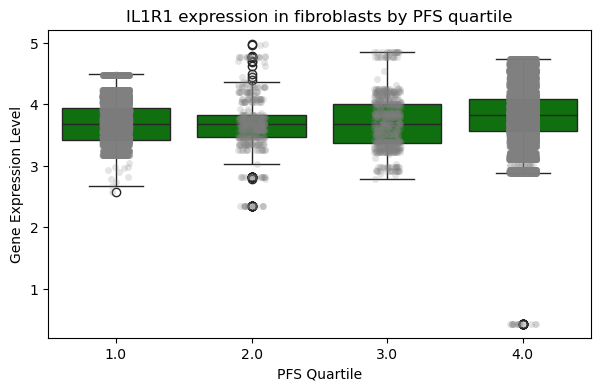

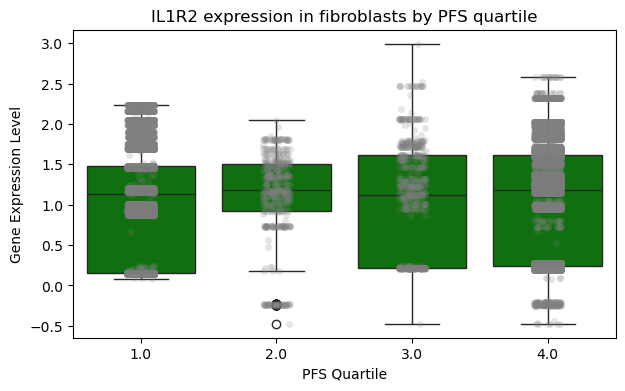

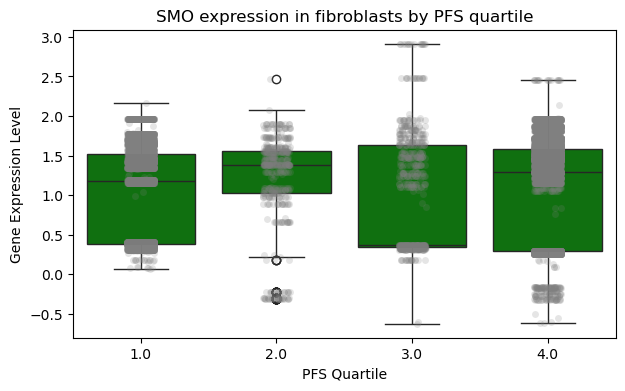

In [56]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_quartile_b12_x",y=gene,data=fibr_gene_expression_modified, color='green')
    sns.stripplot(x="PFS_quartile_b12_x", y=gene, data=fibr_gene_expression_modified, color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by PFS quartile")
    plt.xlabel("PFS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

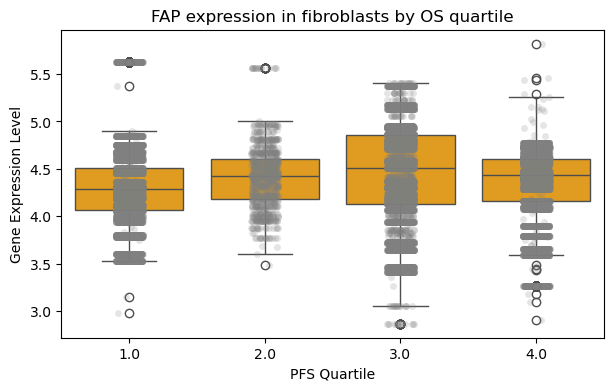

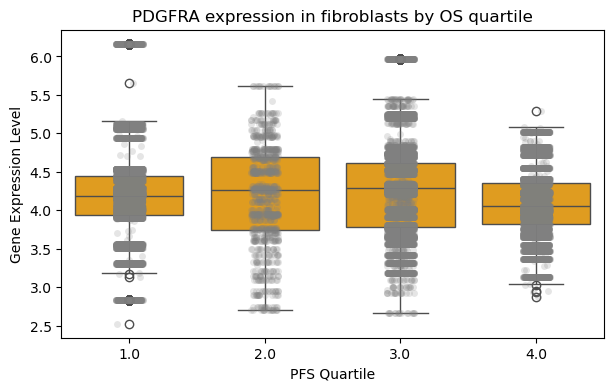

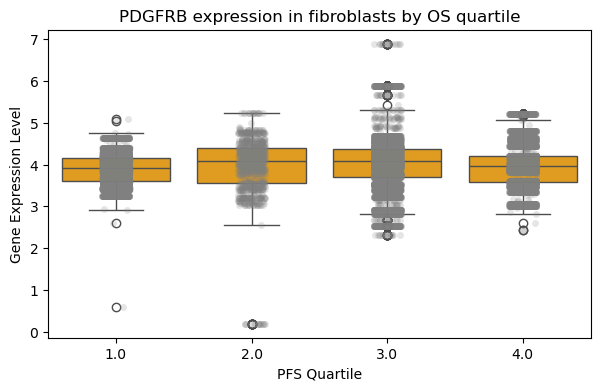

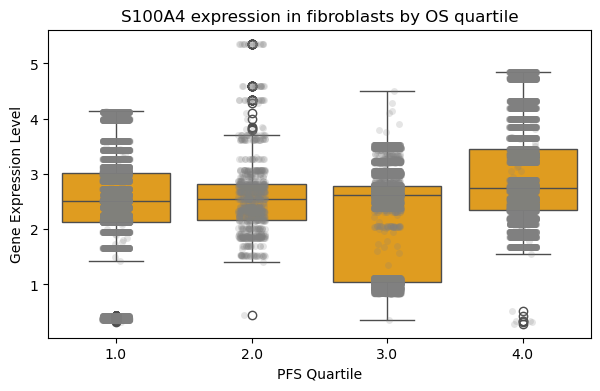

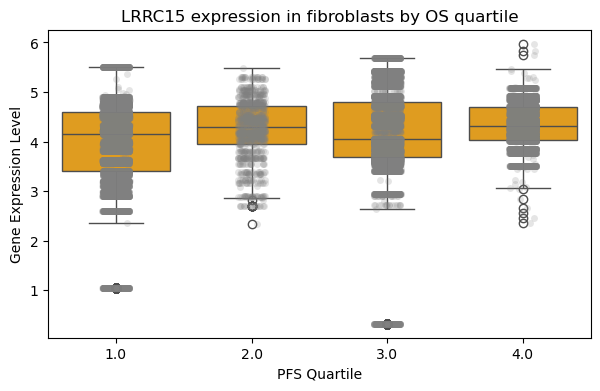

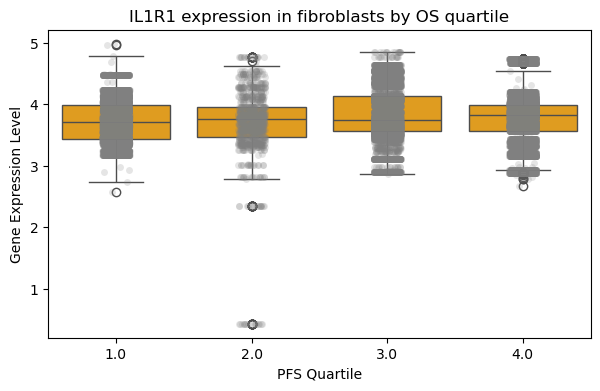

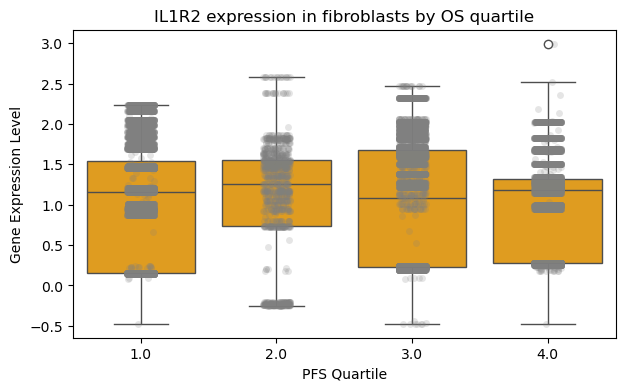

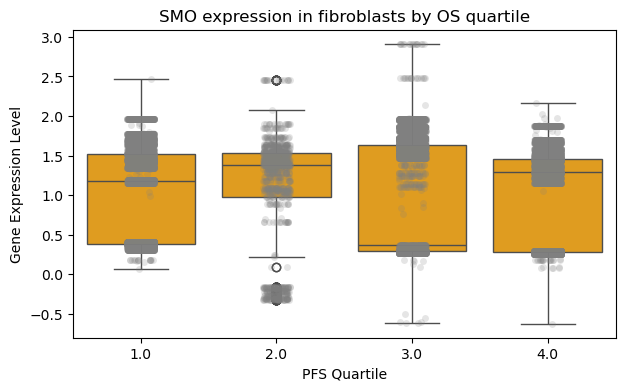

In [55]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="OS_quartile_b12_x",y=gene,data=fibr_gene_expression_modified, color='orange')
    sns.stripplot(x="OS_quartile_b12_x", y=gene, data=fibr_gene_expression_modified, color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by OS quartile")
    plt.xlabel("PFS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

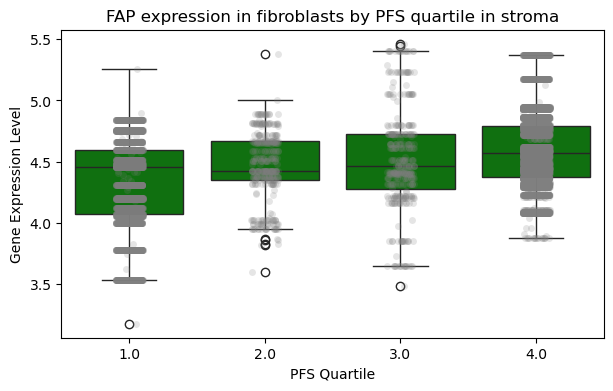

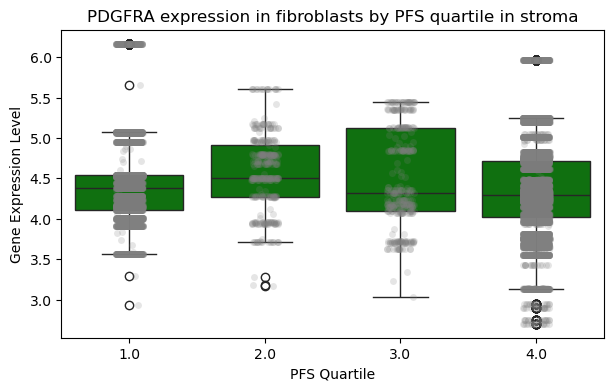

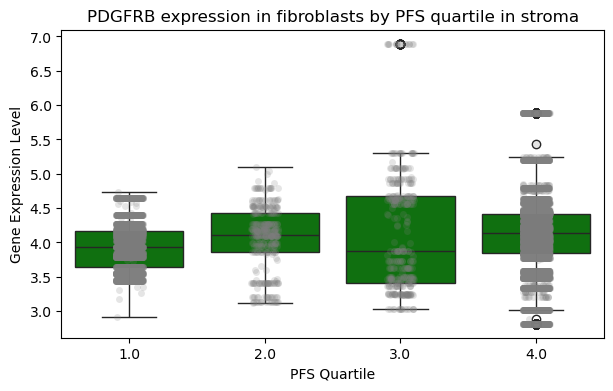

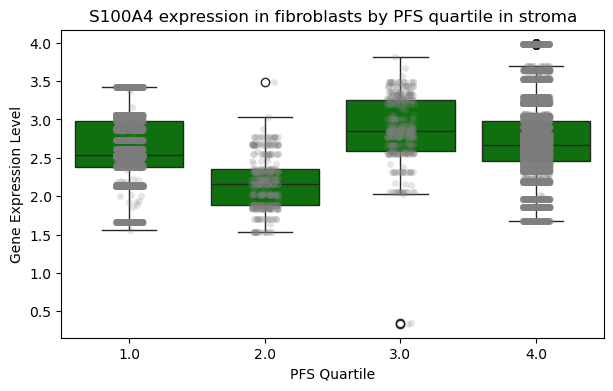

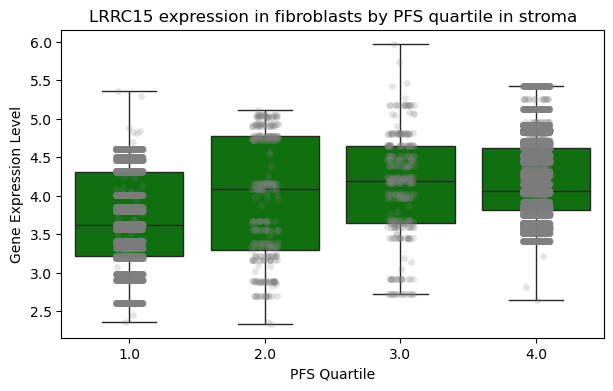

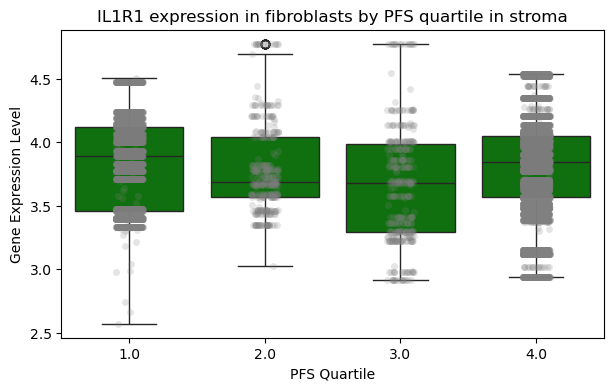

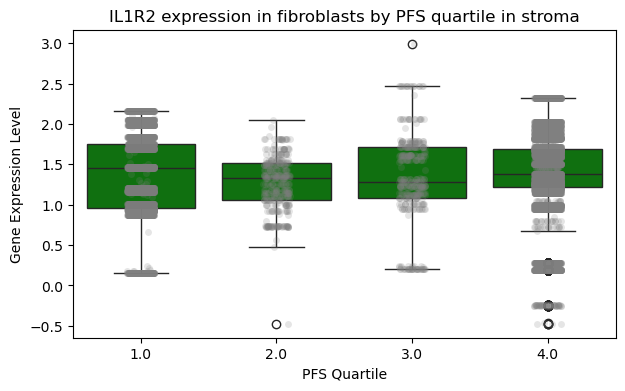

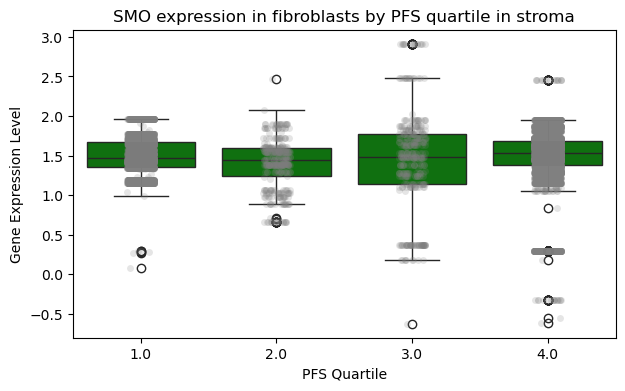

In [57]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_quartile_b12_x",y=gene,data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='green')
    sns.stripplot(x="PFS_quartile_b12_x", y=gene, data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by PFS quartile in stroma")
    plt.xlabel("PFS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

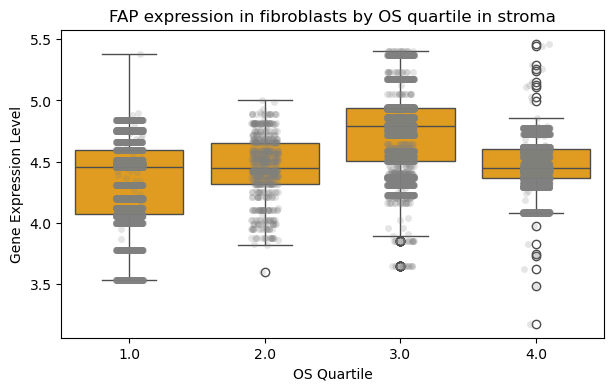

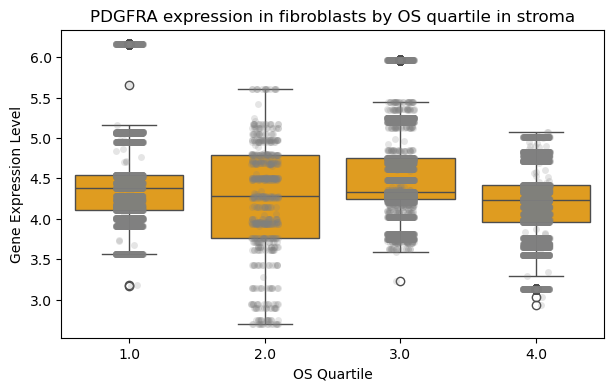

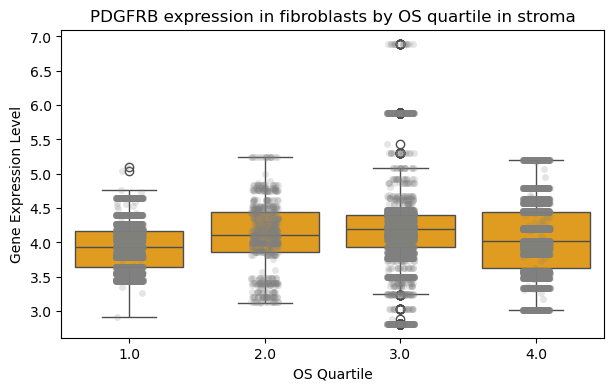

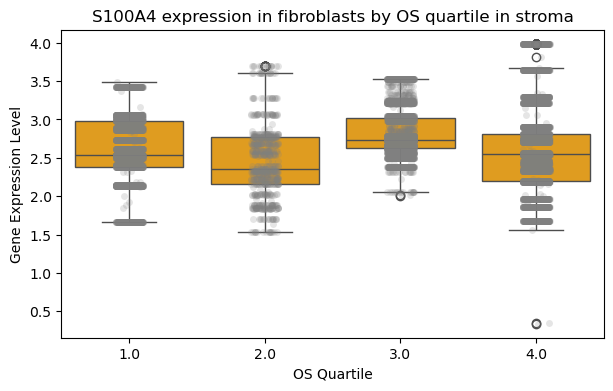

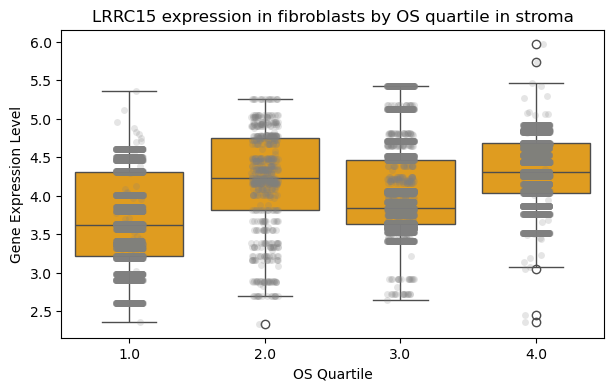

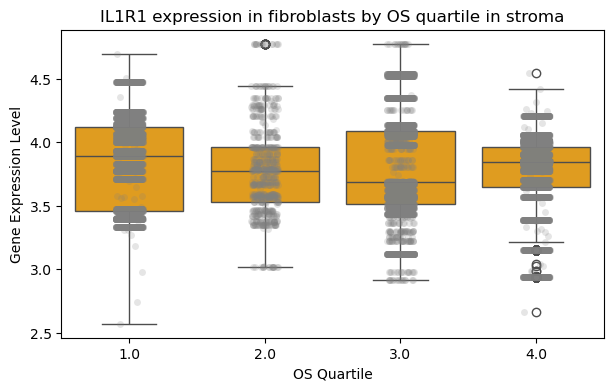

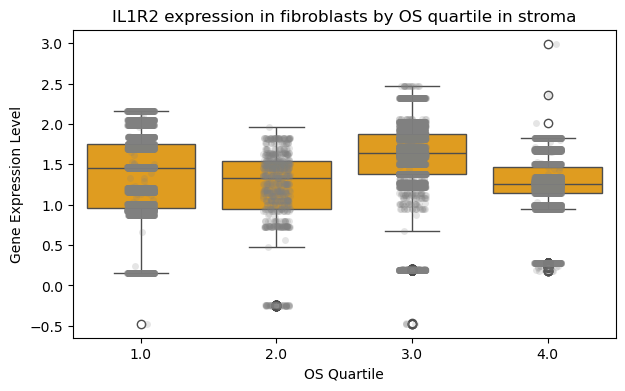

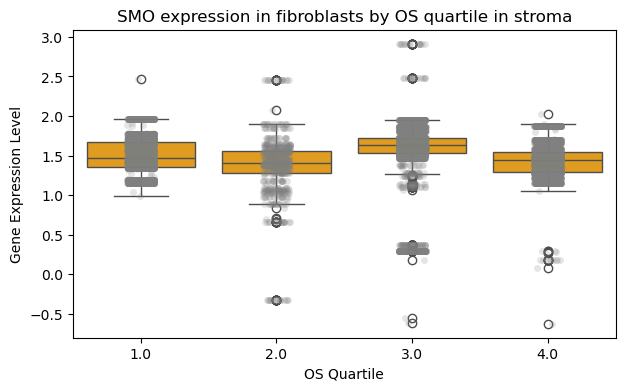

In [58]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="OS_quartile_b12_x",y=gene,data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='orange')
    sns.stripplot(x="OS_quartile_b12_x", y=gene, data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by OS quartile in stroma")
    plt.xlabel("OS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

In [ ]:
fibr_gene_expression_modified["PFS_HL_group"] = fibr_gene_expression_modified["PFS_quartile_b12_x"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)
fibr_gene_expression_modified["OS_HL_group"] = fibr_gene_expression_modified["OS_quartile_b12_x"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)

0    Low
1    Low
2    Low
3    Low
4    Low
5    Low
6    Low
7    Low
8    Low
9    Low
Name: PFS_HL_group, dtype: object

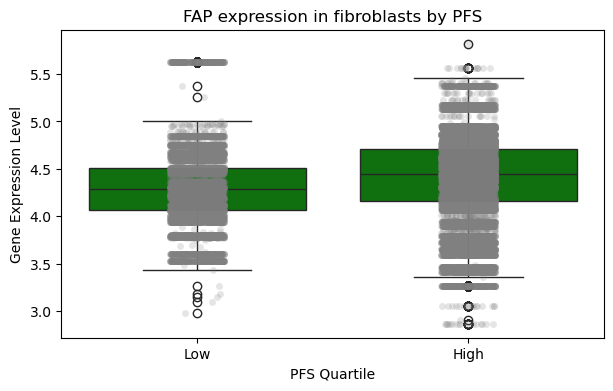

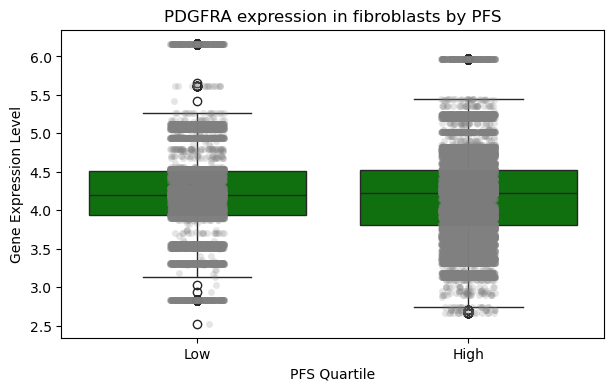

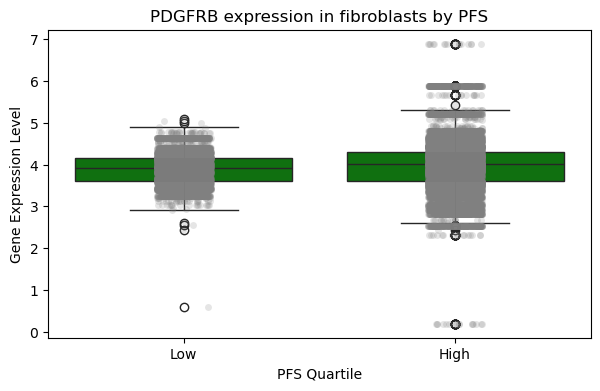

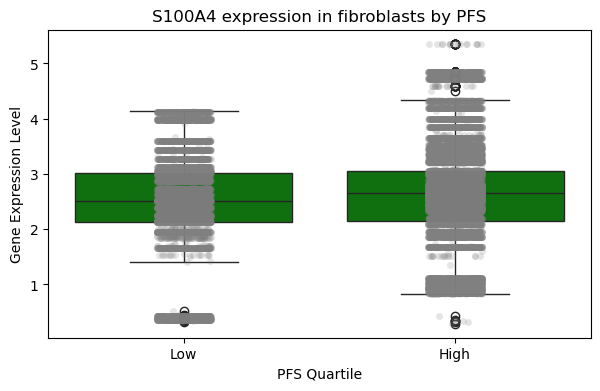

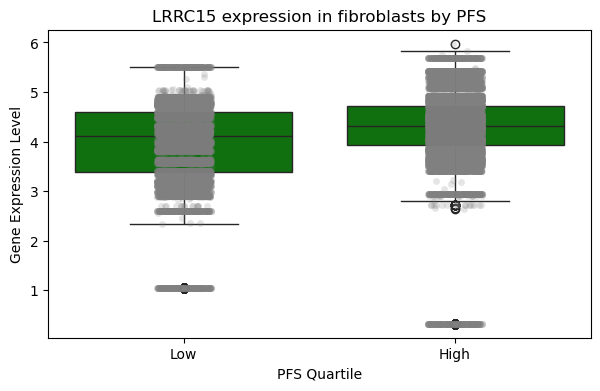

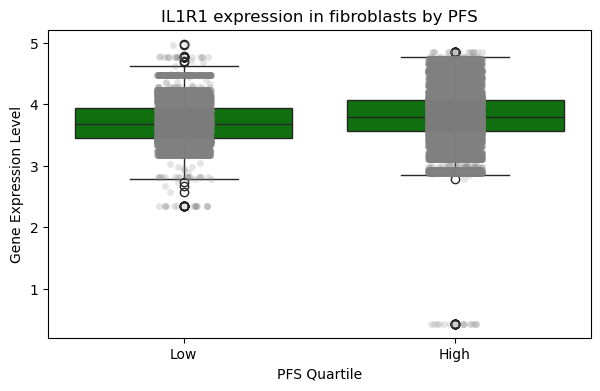

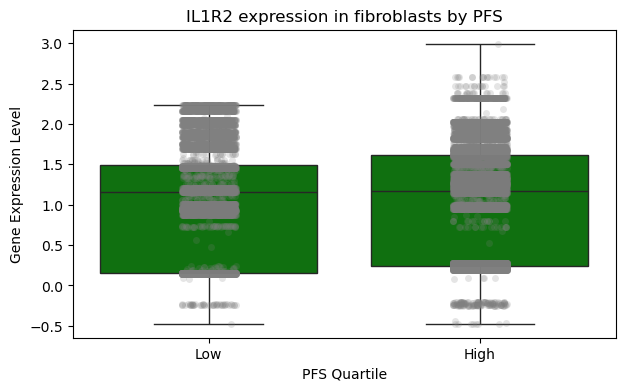

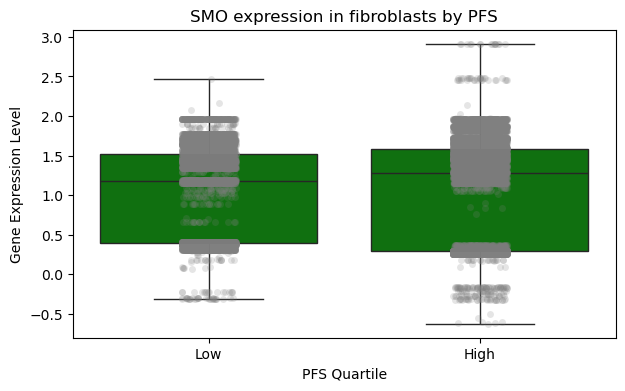

In [63]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=gene,data=fibr_gene_expression_modified, color='green')
    sns.stripplot(x="PFS_HL_group", y=gene, data=fibr_gene_expression_modified, color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by PFS")
    plt.xlabel("PFS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

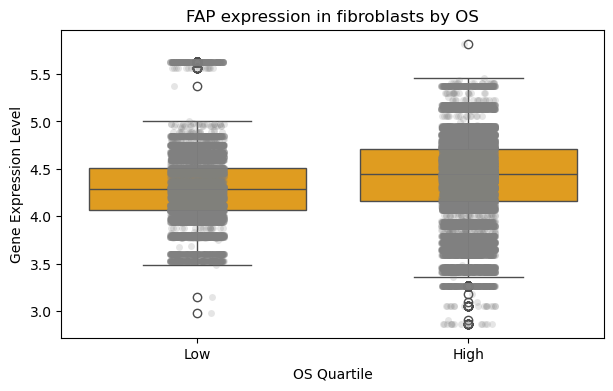

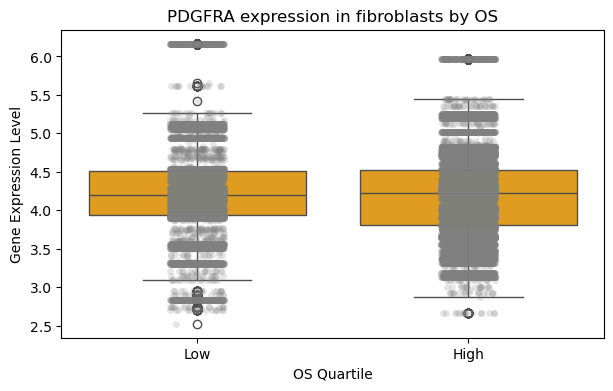

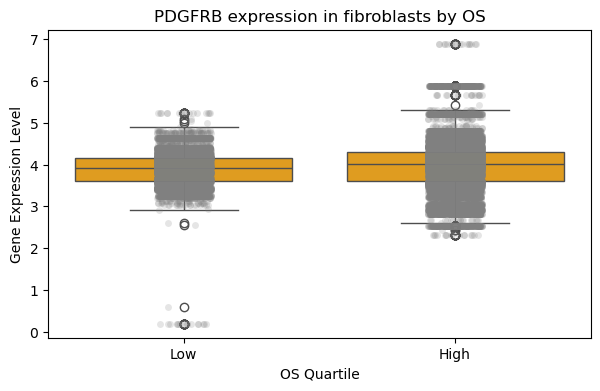

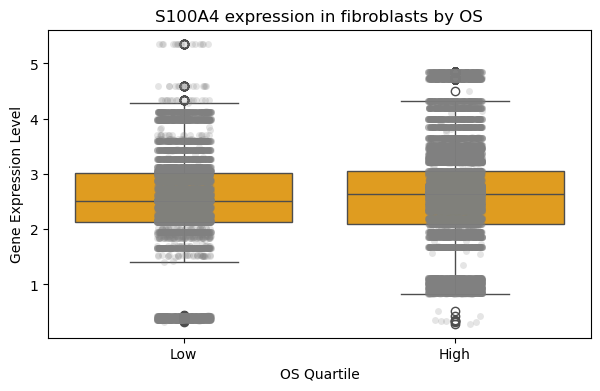

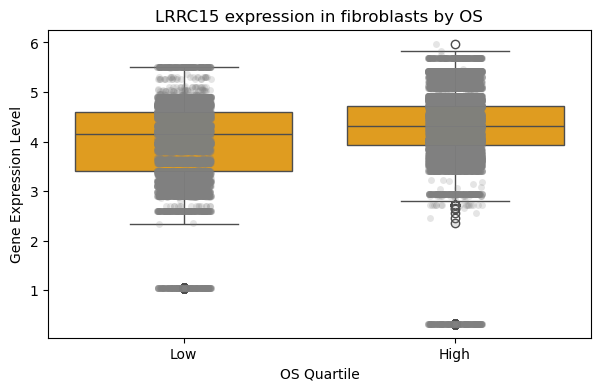

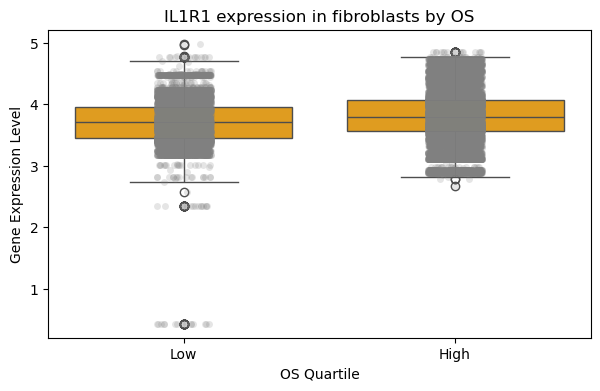

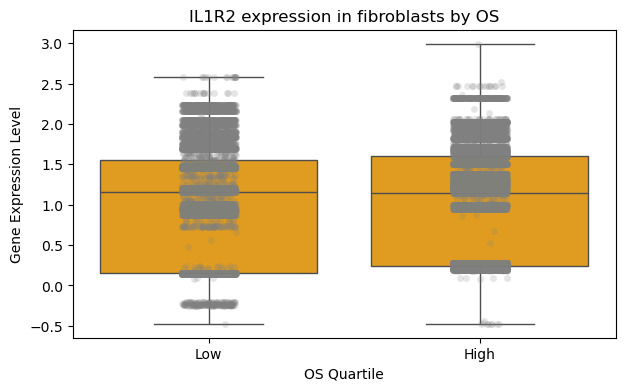

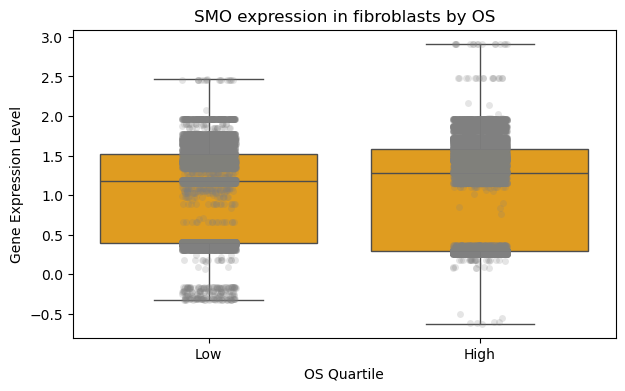

In [64]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="OS_HL_group",y=gene,data=fibr_gene_expression_modified, color='orange')
    sns.stripplot(x="OS_HL_group", y=gene, data=fibr_gene_expression_modified, color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by OS")
    plt.xlabel("OS Quartile")
    plt.ylabel("Gene Expression Level")
    plt.show()

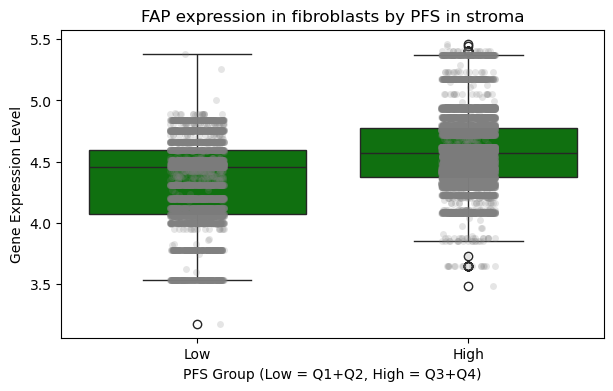

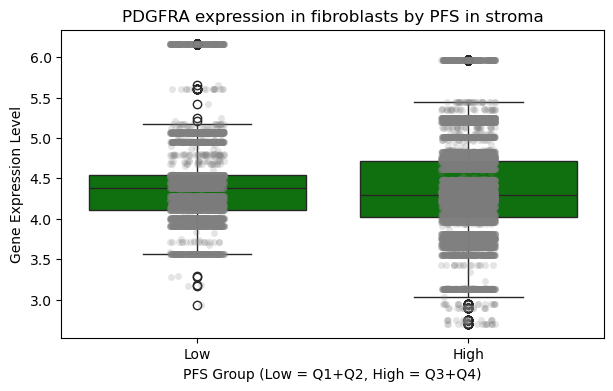

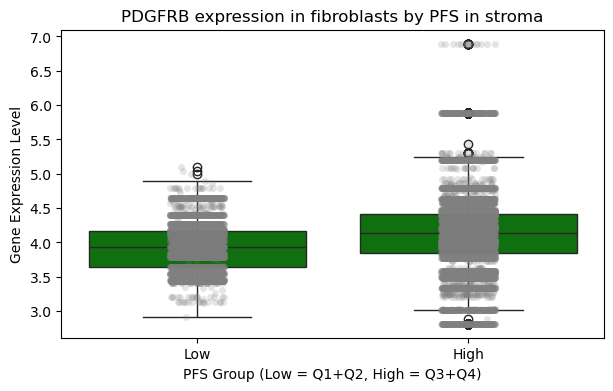

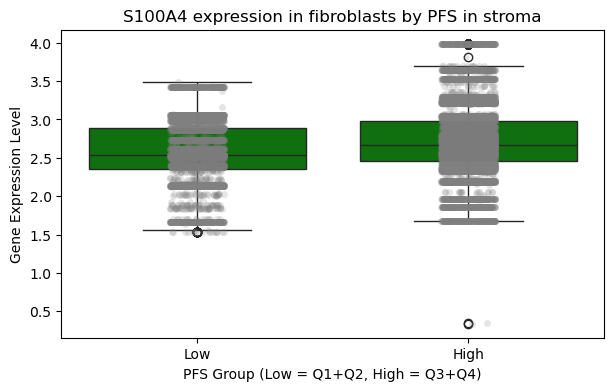

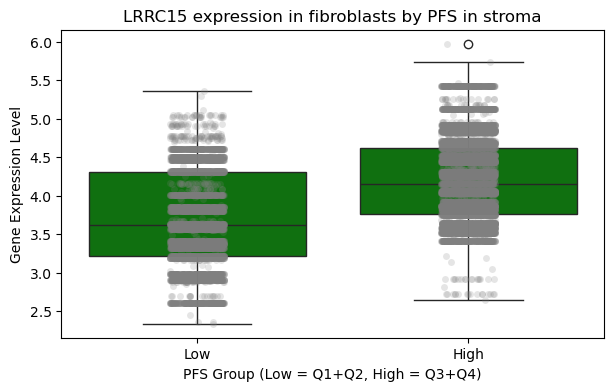

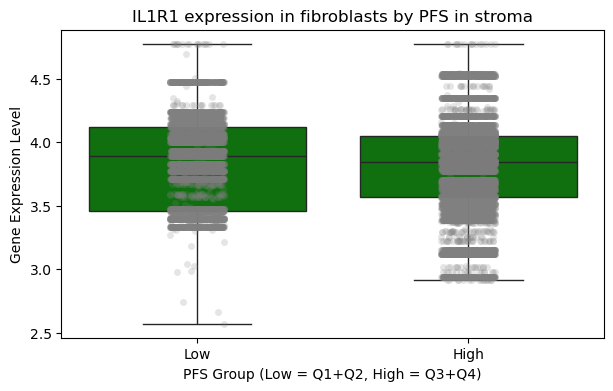

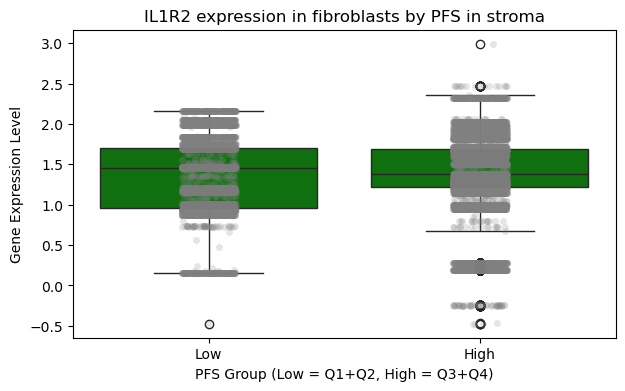

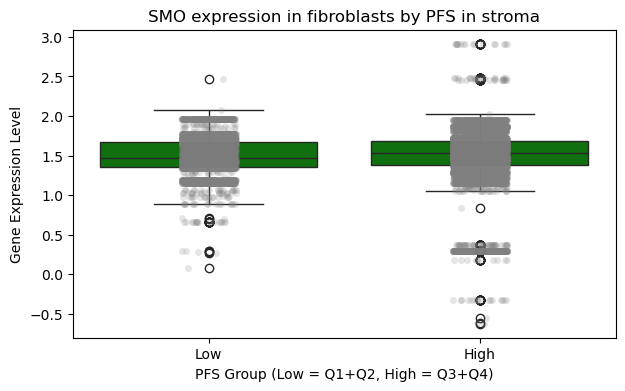

In [68]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=gene,data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='green')
    sns.stripplot(x="PFS_HL_group", y=gene, data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by PFS in stroma")
    plt.xlabel("PFS Group (Low = Q1+Q2, High = Q3+Q4)")
    plt.ylabel("Gene Expression Level")
    plt.show()

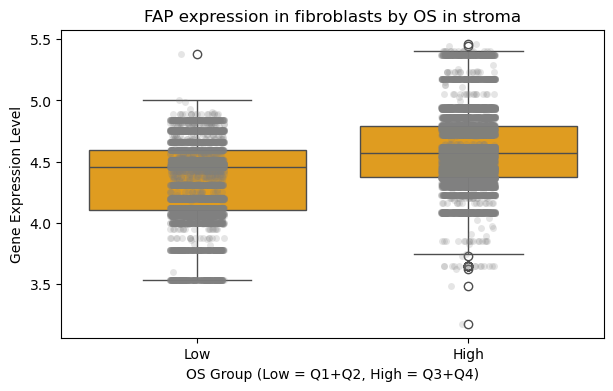

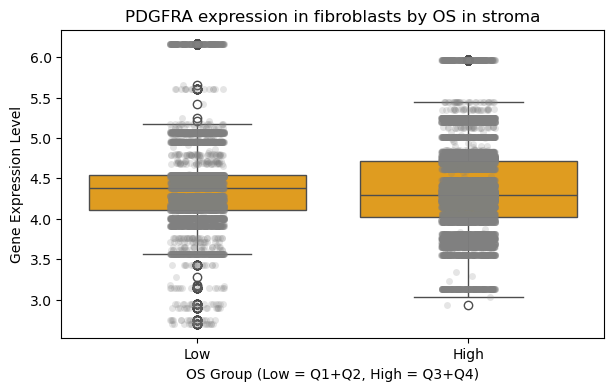

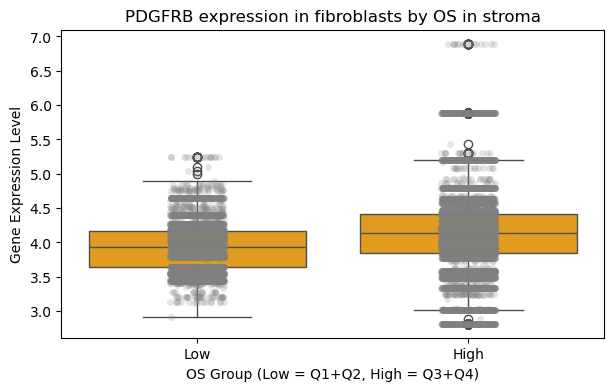

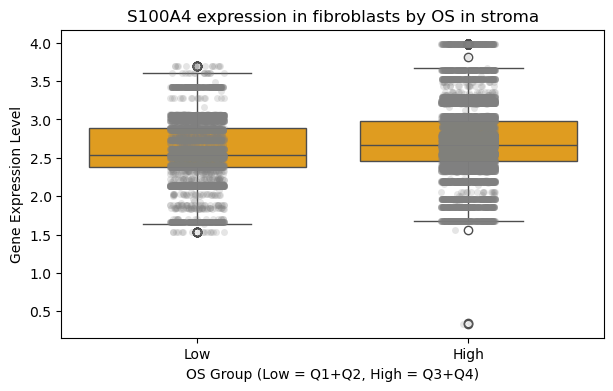

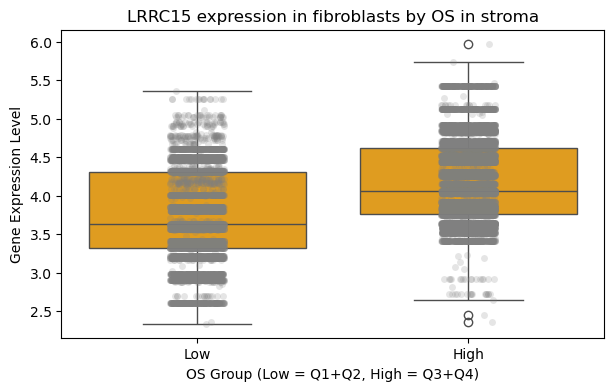

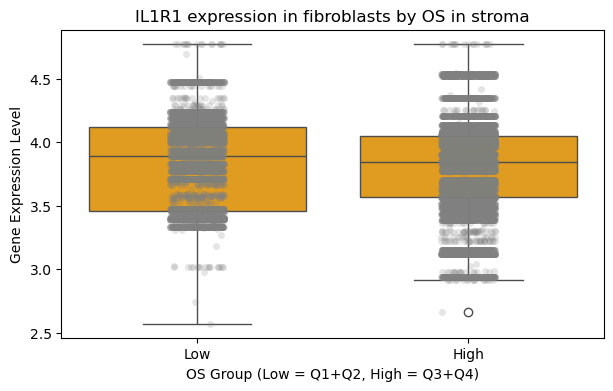

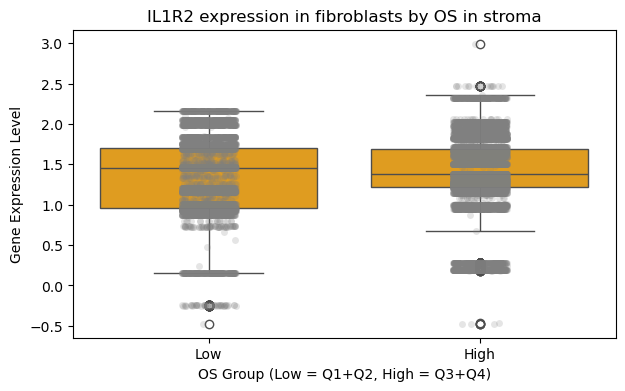

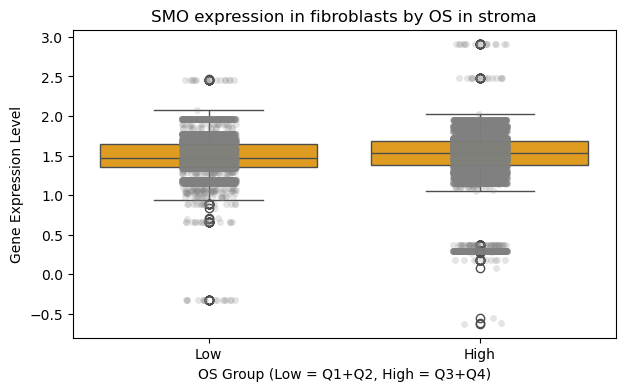

In [ ]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="OS_HL_group",y=gene,data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='orange')
    sns.stripplot(x="OS_HL_group", y=gene, data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by OS in stroma")
    plt.xlabel("OS Group (Low = Q1+Q2, High = Q3+Q4)")
    plt.ylabel("Gene Expression Level")
    plt.show()

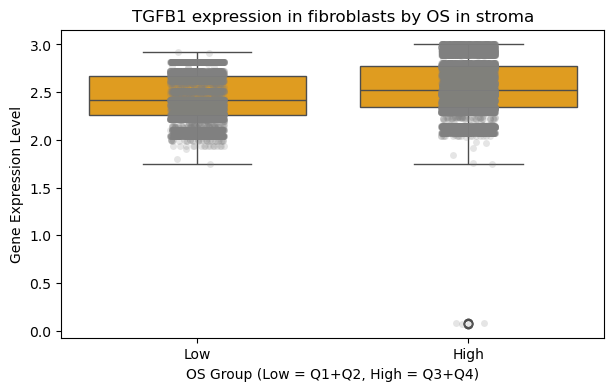

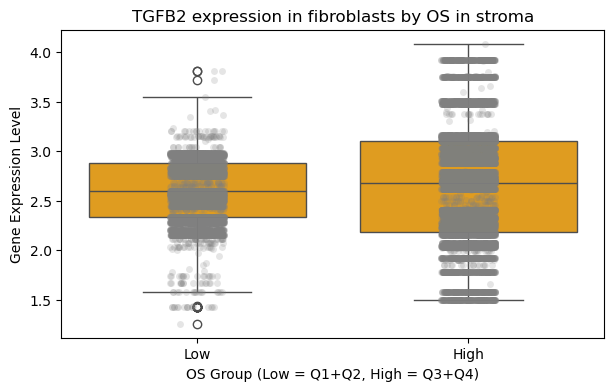

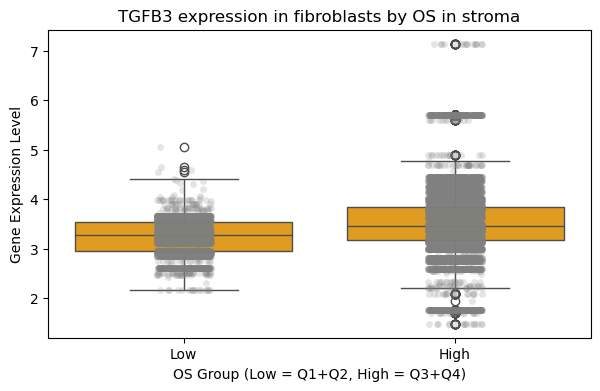

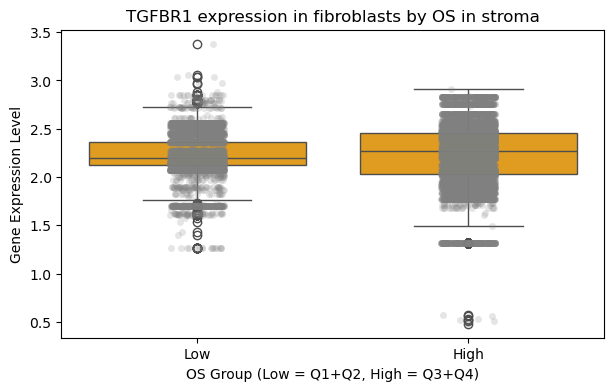

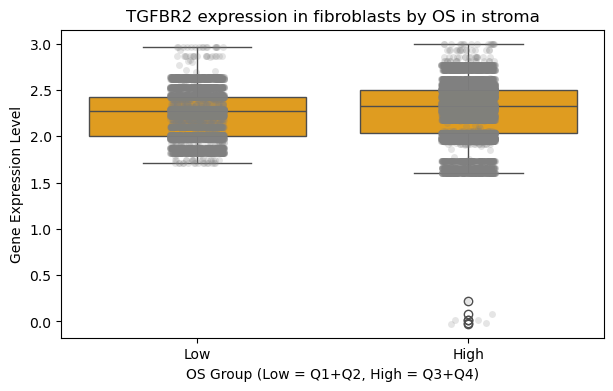

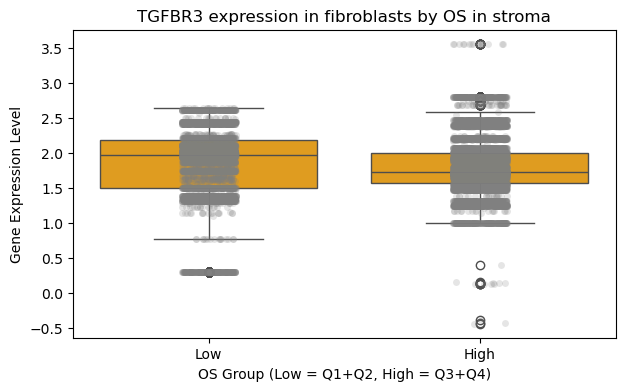

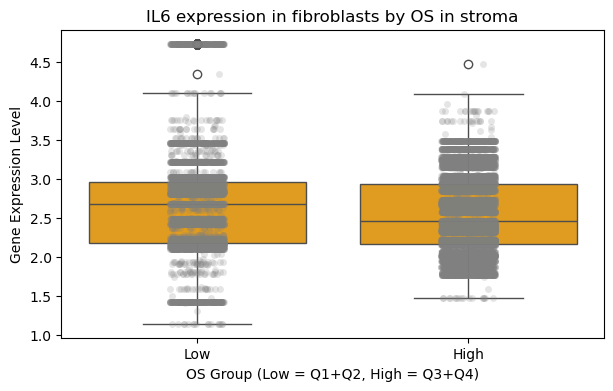

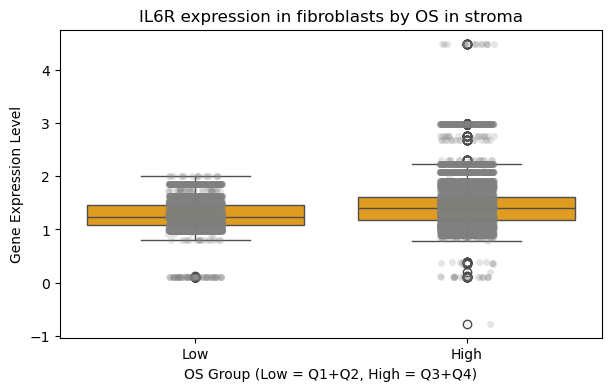

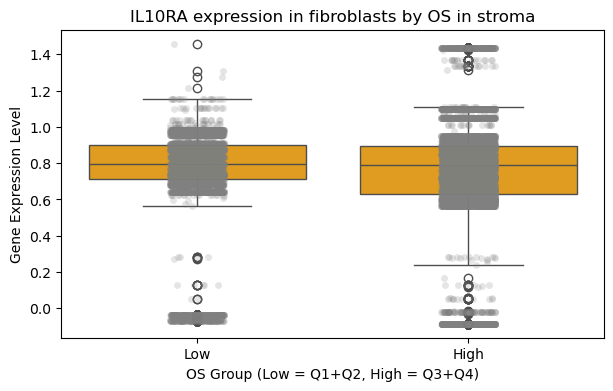

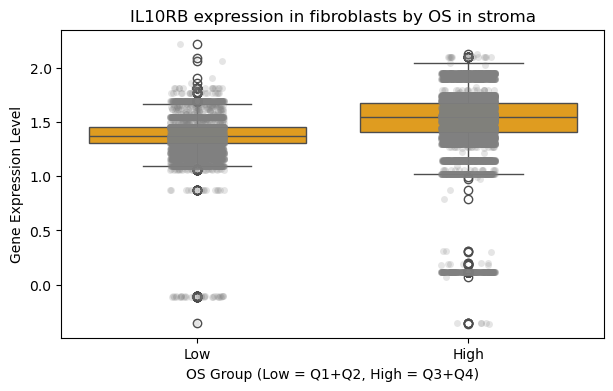

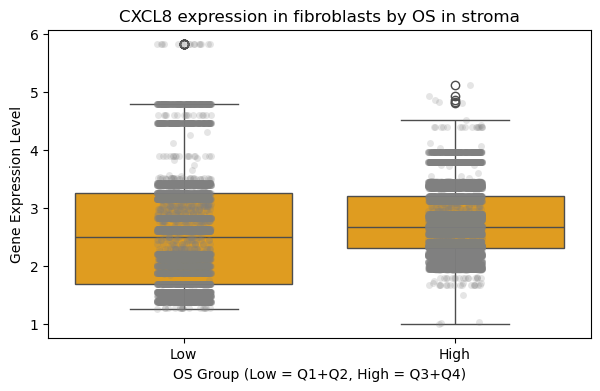

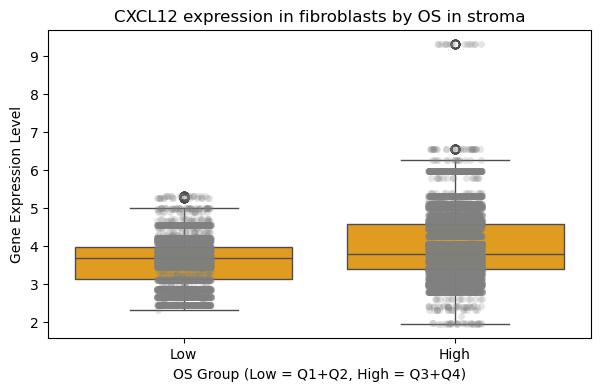

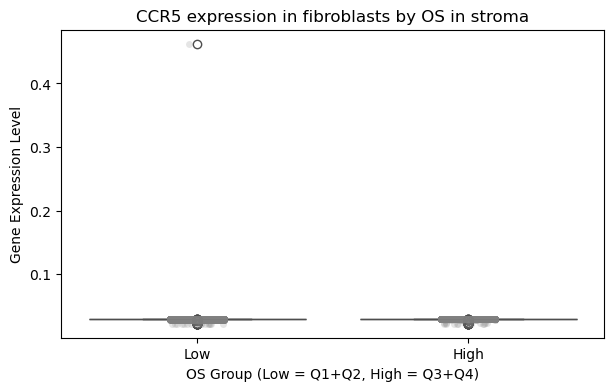

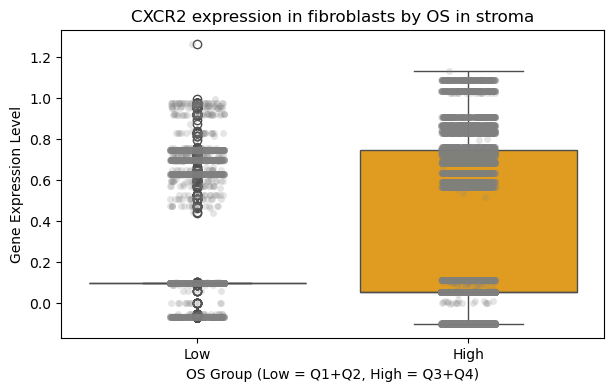

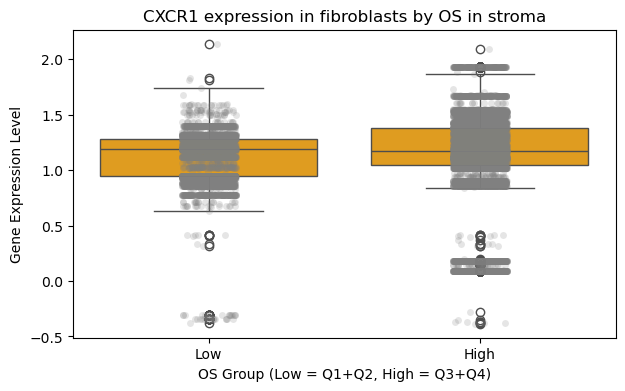

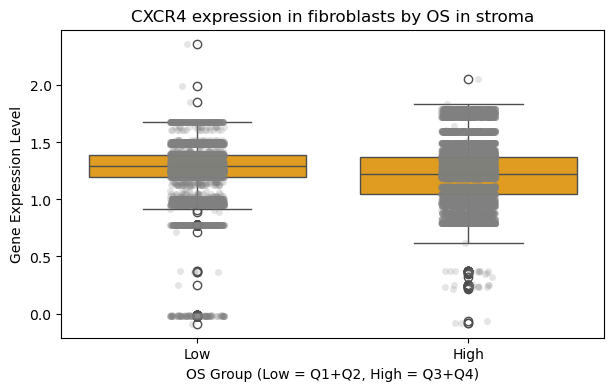

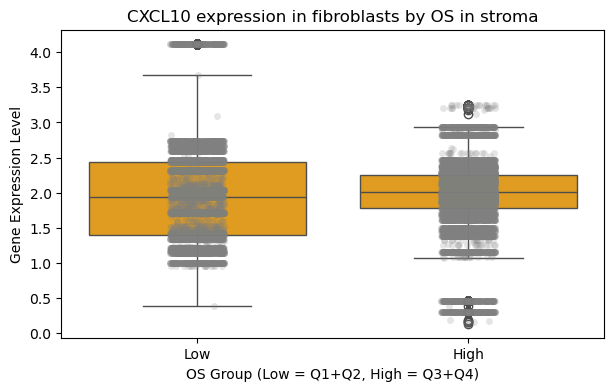

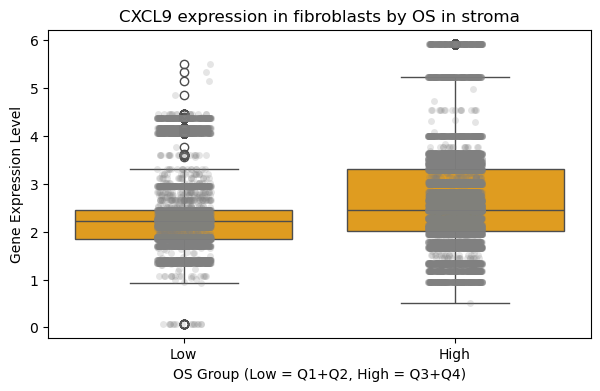

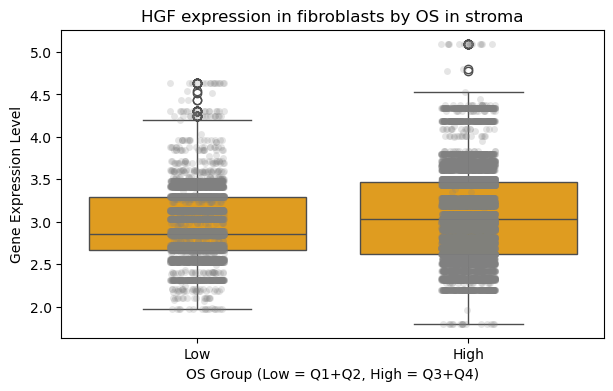

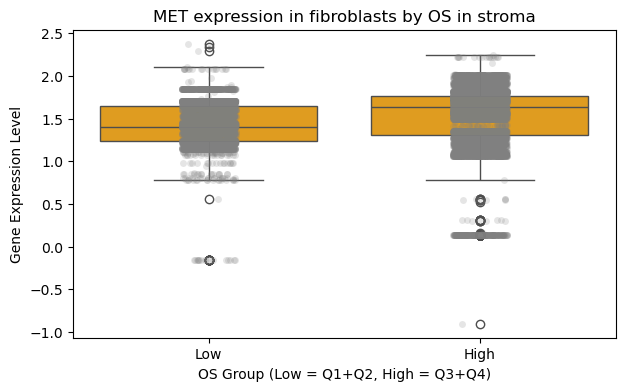

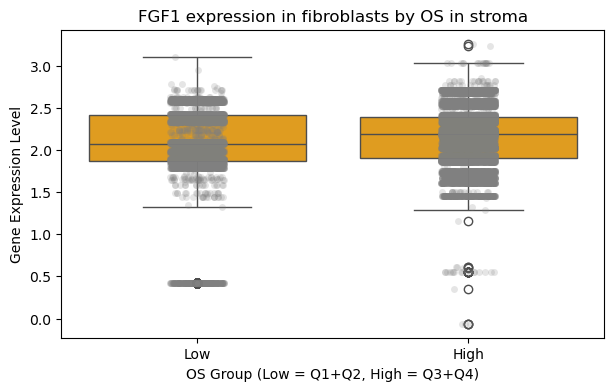

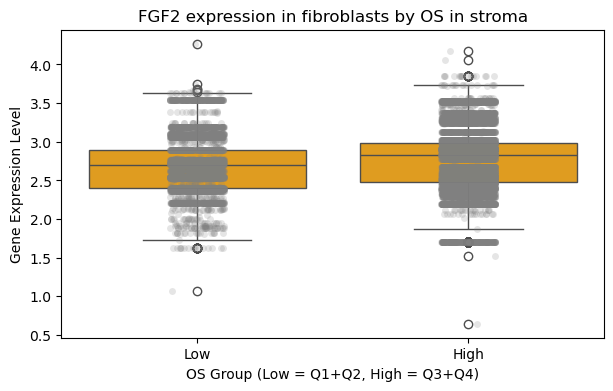

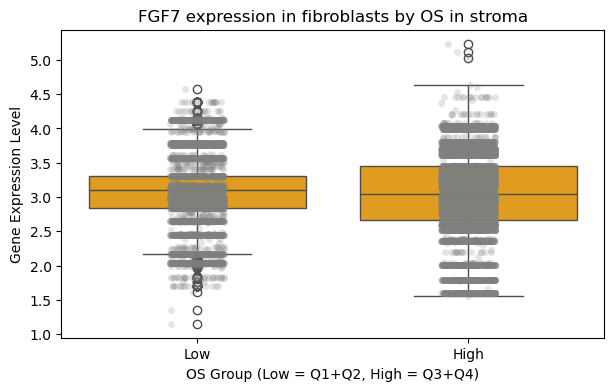

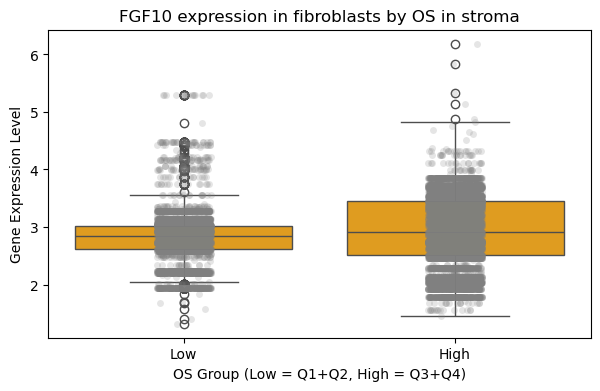

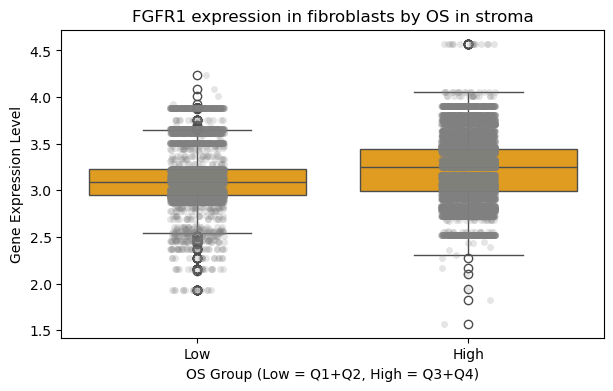

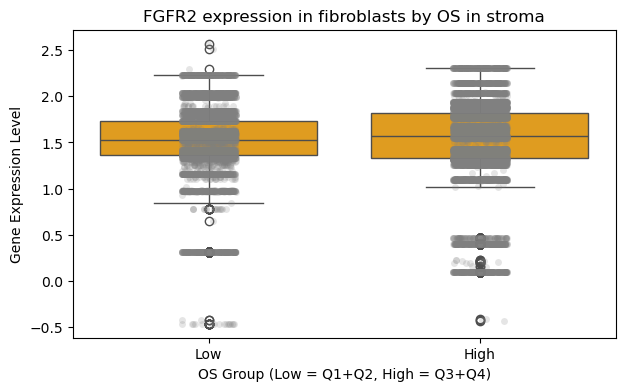

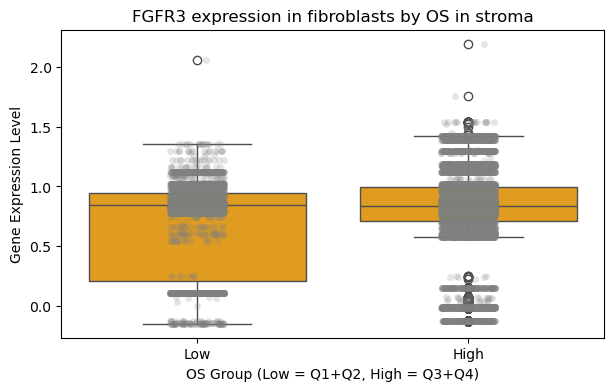

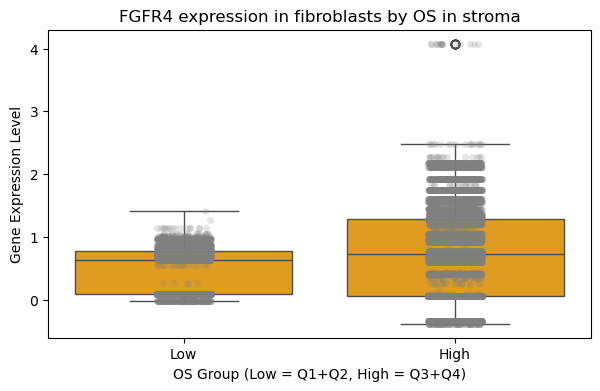

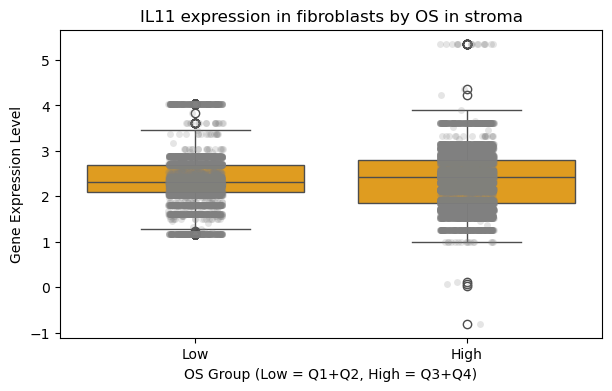

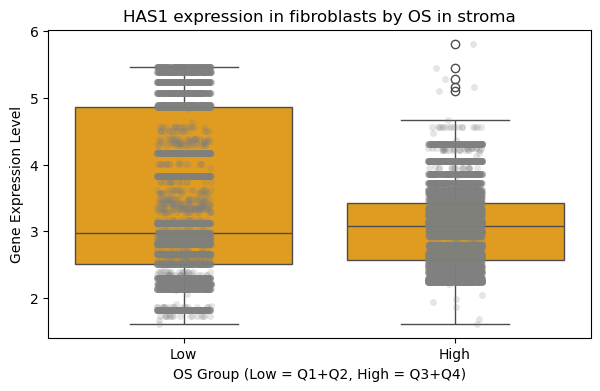

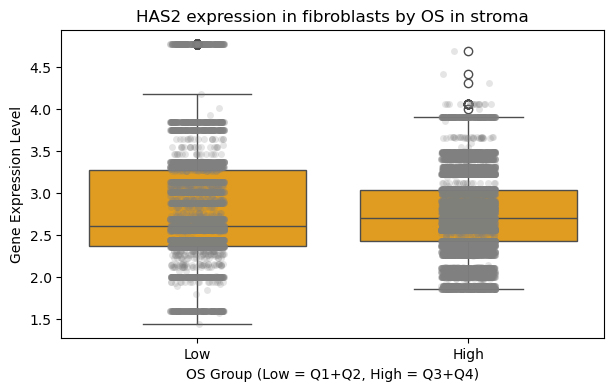

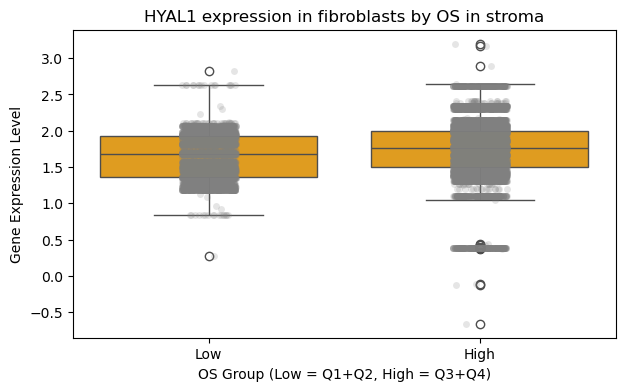

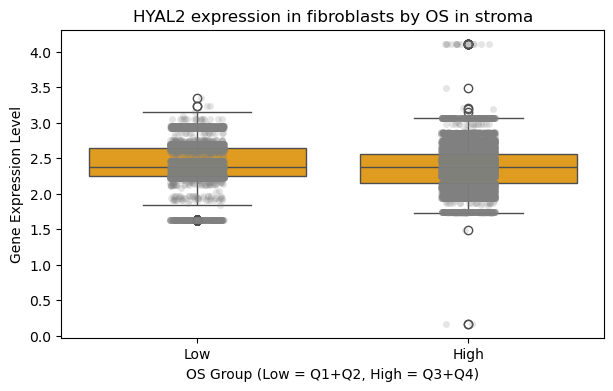

In [69]:
for gene in target_receptors_molecules:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="OS_HL_group",y=gene,data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='orange')
    sns.stripplot(x="OS_HL_group", y=gene, data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by OS in stroma")
    plt.xlabel("OS Group (Low = Q1+Q2, High = Q3+Q4)")
    plt.ylabel("Gene Expression Level")
    plt.show()

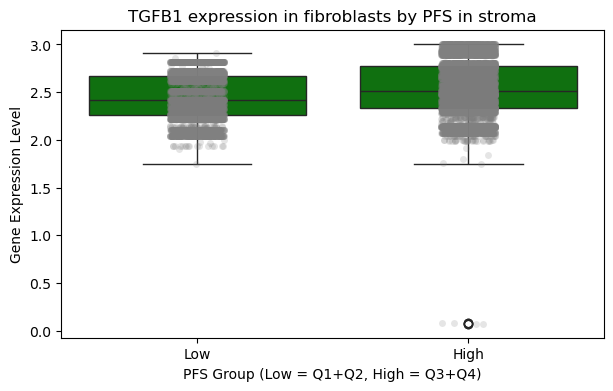

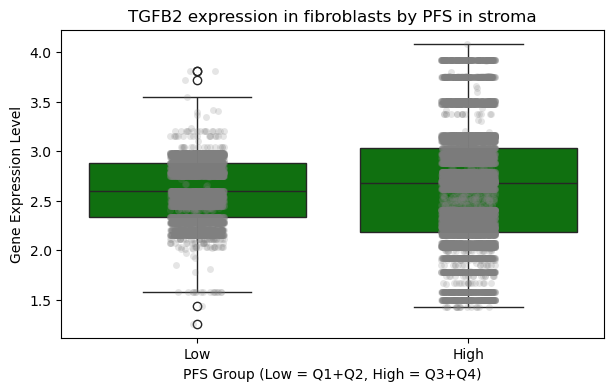

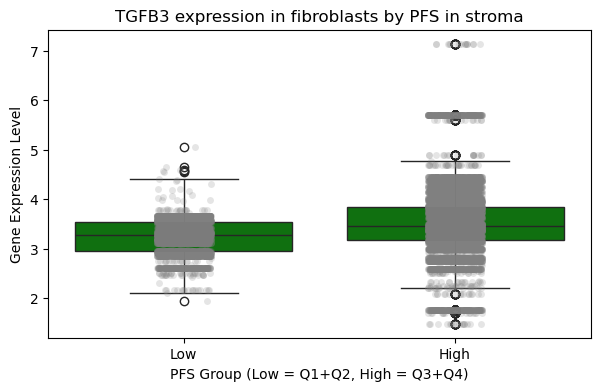

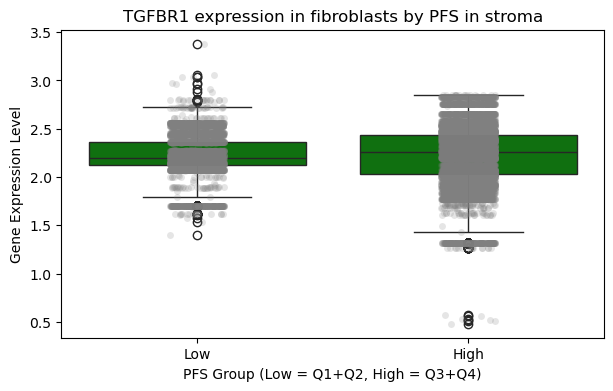

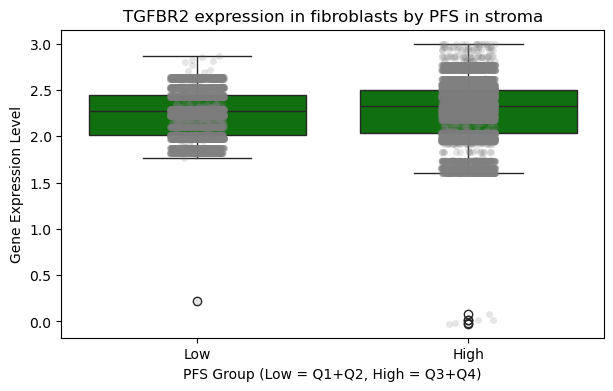

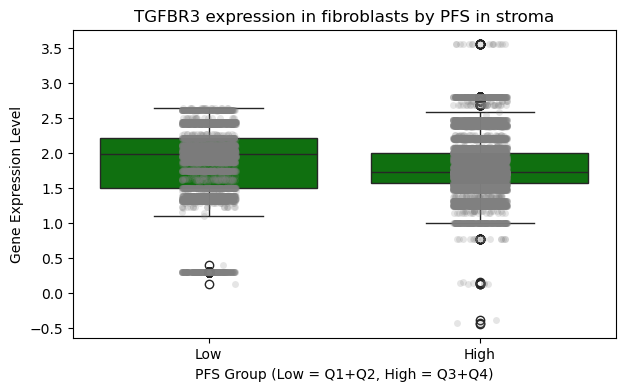

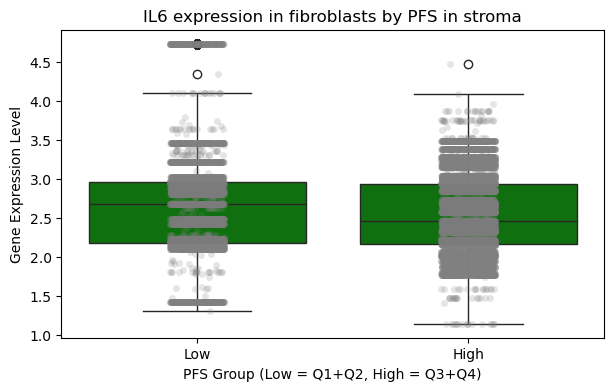

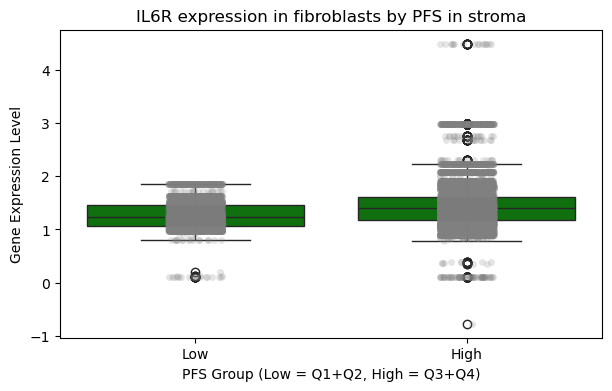

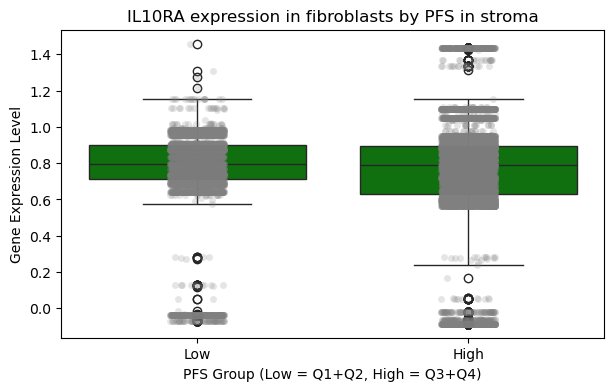

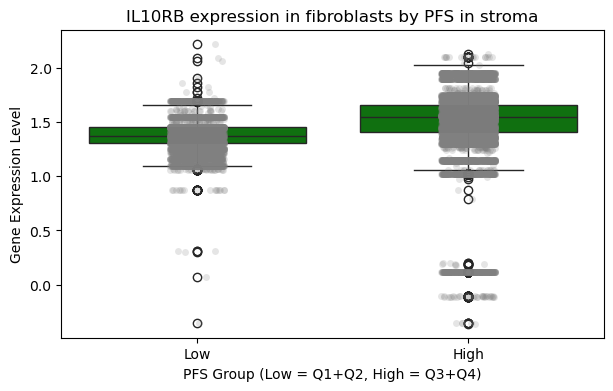

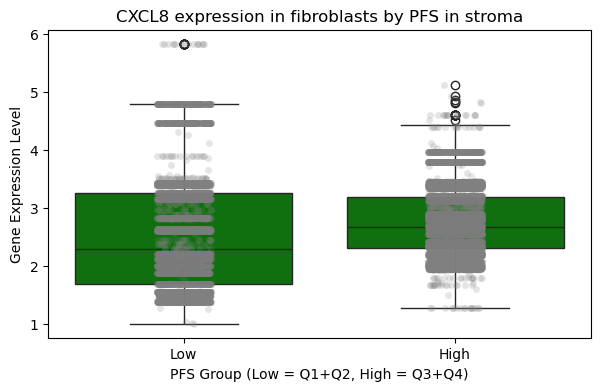

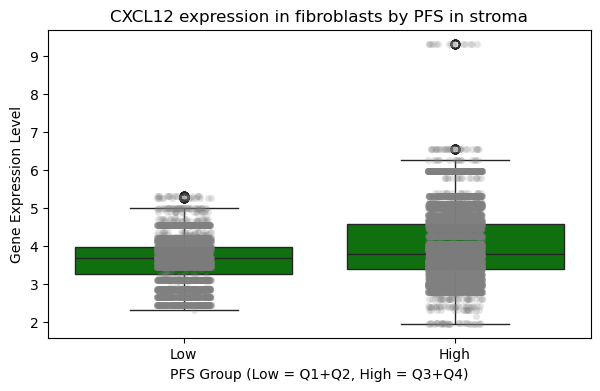

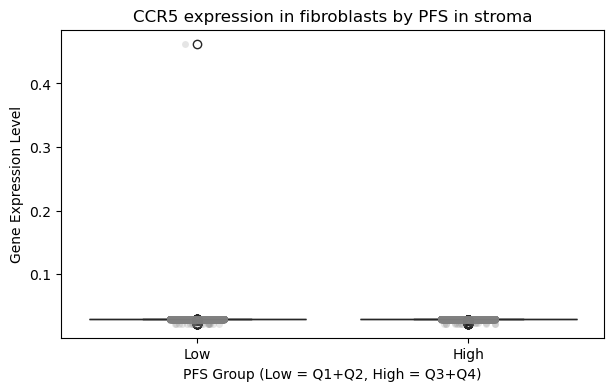

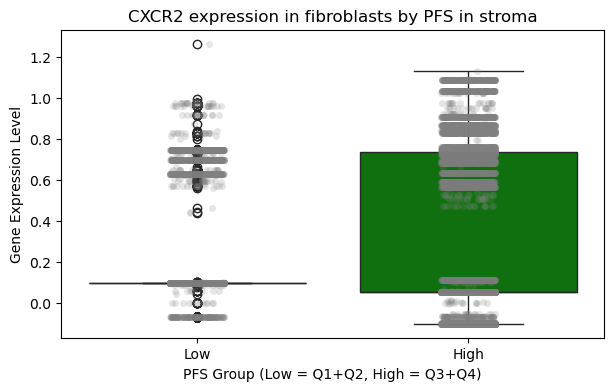

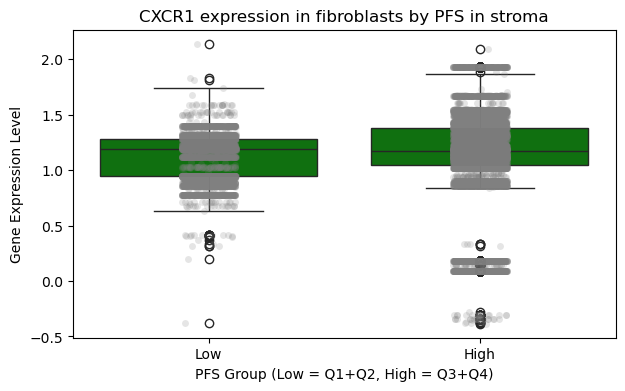

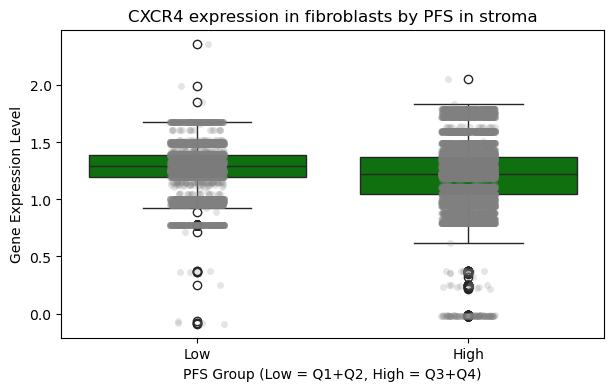

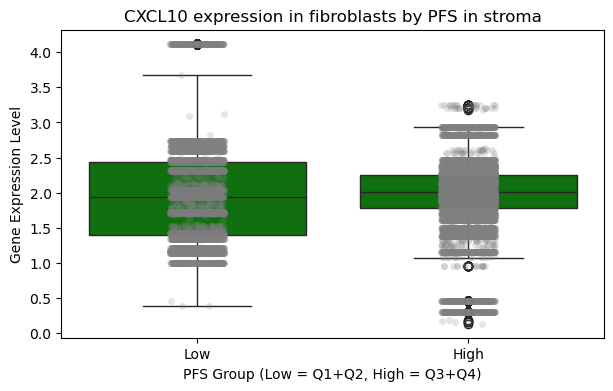

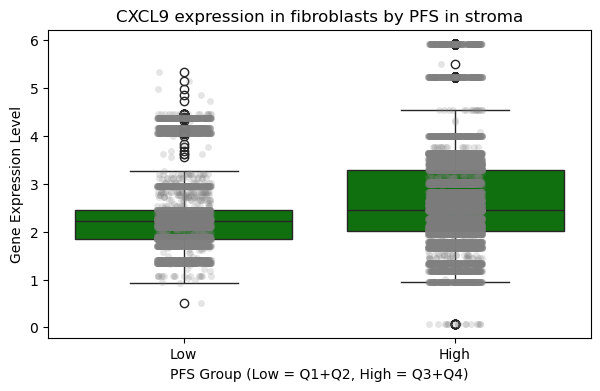

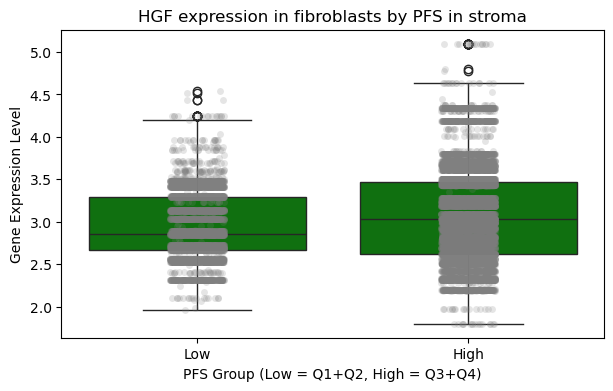

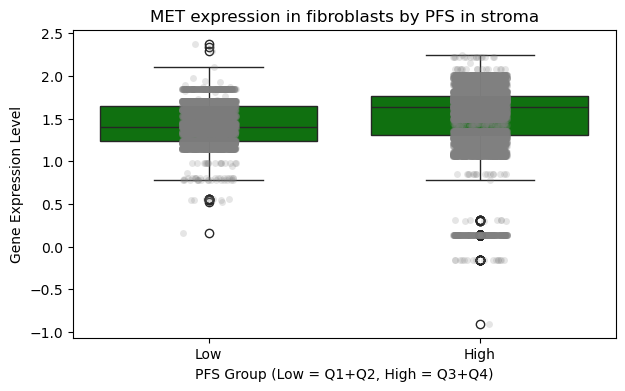

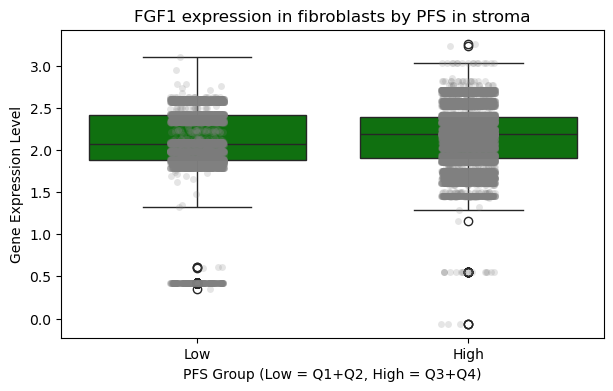

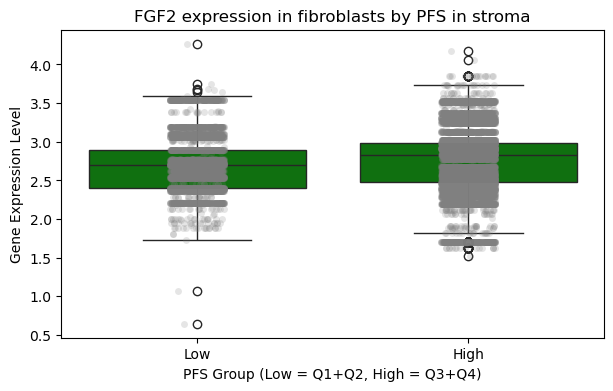

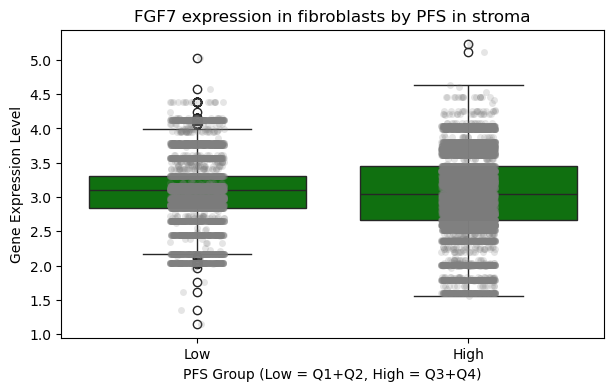

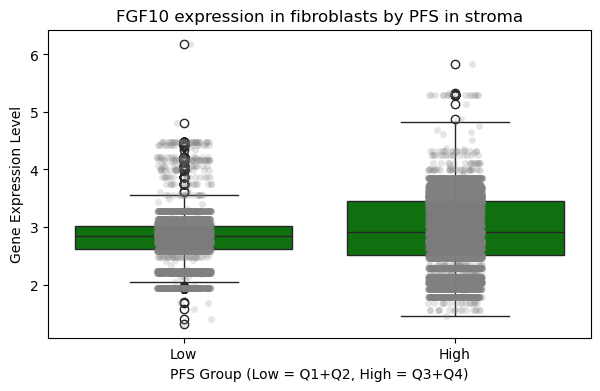

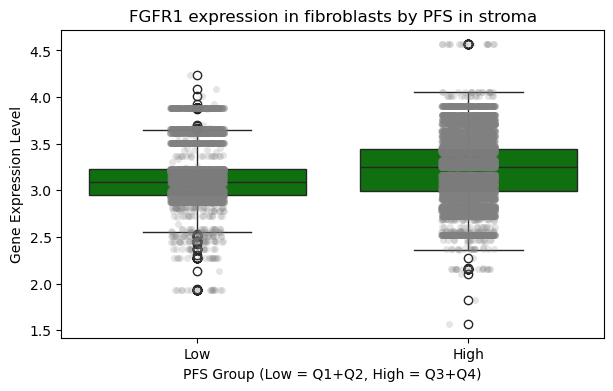

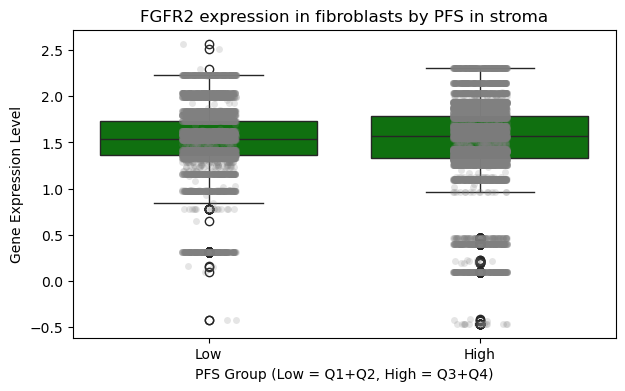

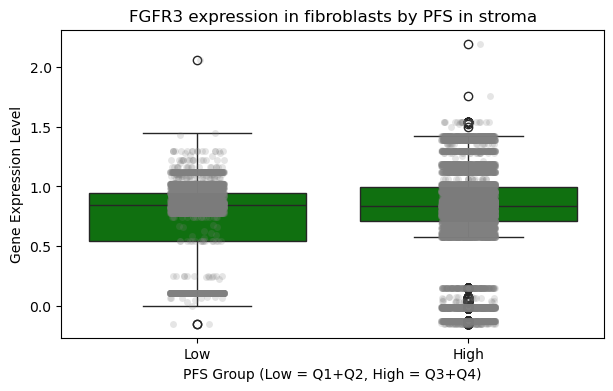

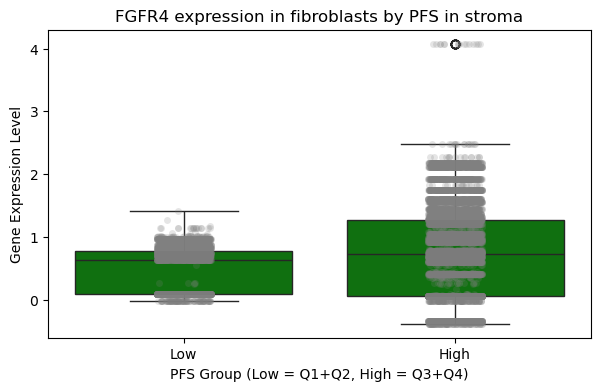

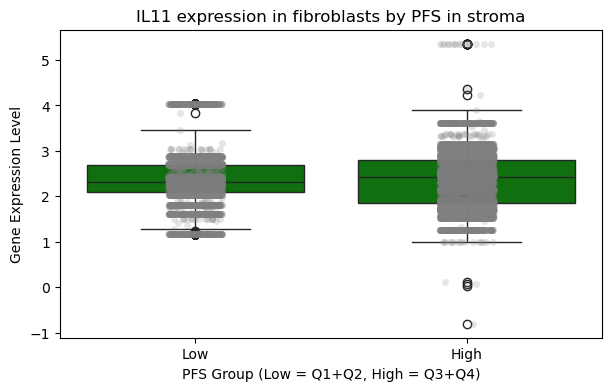

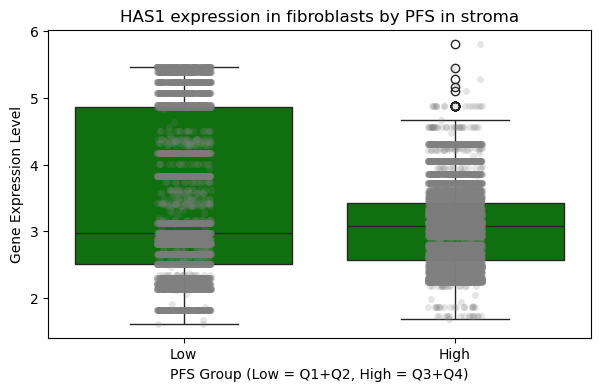

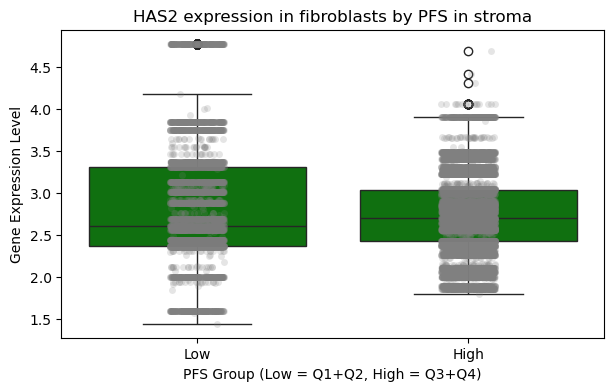

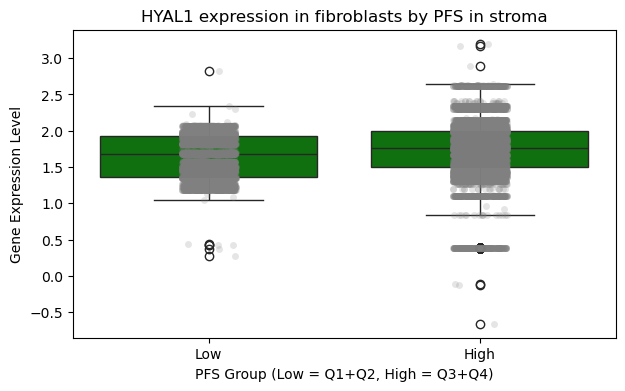

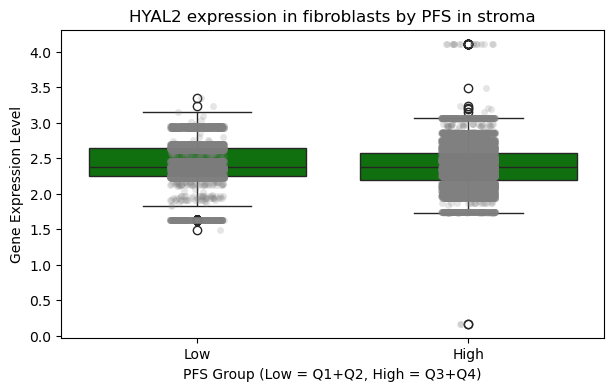

In [71]:
for gene in target_receptors_molecules:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="PFS_HL_group",y=gene,data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='green')
    sns.stripplot(x="PFS_HL_group", y=gene, data=fibr_gene_expression_modified.loc[fibr_gene_expression_modified['Segment']=="stroma"], color='grey', alpha=0.2, jitter=True)
    plt.title(f"{gene} expression in fibroblasts by PFS in stroma")
    plt.xlabel("PFS Group (Low = Q1+Q2, High = Q3+Q4)")
    plt.ylabel("Gene Expression Level")
    plt.show()